# Step 2: Exploratory Data Analysis
## Cancer Survivorship & Cardiometabolic Comorbidities in NHANES 1999-2018

**Research Question:** Among US adults with a cancer history, are cardiometabolic comorbidities (diabetes, hypertension, obesity) independently associated with all-cause mortality?

**Study Design:** Retrospective cohort using NHANES linked mortality data

**Data Source:** CDC NHANES 1999-2018 (10 two-year cycles) + NCHS Linked Mortality Files

---

### EDA Objectives
1. Understand variable structure from one cycle (2017-2018)
2. Map key variables across all components
3. Parse and validate mortality linkage files
4. Assess missingness patterns
5. Visualize distributions of key exposures and outcomes
6. Estimate cancer survivor sample size across all cycles
7. Generate cross-tabulations: cancer x comorbidities x mortality

In [1]:
# ============================================================
# STEP 2.1 — Environment Setup
# ============================================================
# Standard scientific Python stack.
# Publication-quality plot settings (Nature/JAMA style).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Publication-quality plot settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})
COLORS = ['#4338CA', '#F472B6', '#10B981', '#F59E0B', '#3B82F6', '#8B5CF6']
sns.set_palette(COLORS)

DATA_DIR = Path('data')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

CYCLES = [
    '1999-2000', '2001-2002', '2003-2004', '2005-2006', '2007-2008',
    '2009-2010', '2011-2012', '2013-2014', '2015-2016', '2017-2018'
]

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Files found: {len(list(DATA_DIR.glob("*")))}')
print('Setup complete.')

Data directory: /Users/shri/portfolio/Projects/nhanes-cancer-survival/data
Files found: 80
Setup complete.


---
## 2.2 — Load One Cycle (2017-2018) to Understand Structure

We start with the most recent cycle to understand variable names, coding, and structure before scaling to all 10 cycles.

**Components to examine:**
| File | Content | Key Variables |
|------|---------|---------------|
| DEMO | Demographics | RIDAGEYR (age), RIAGENDR (sex), RIDRETH1 (race/ethnicity) |
| MCQ | Medical Conditions | MCQ220 (ever told had cancer), MCQ230A-D (cancer type) |
| DIQ | Diabetes | DIQ010 (diabetes status) |
| BMX | Body Measures | BMXBMI (BMI) |
| BPQ | Blood Pressure | BPQ020 (hypertension status) |
| SMQ | Smoking | SMQ020 (smoked 100 cigs), SMQ040 (current smoking) |
| GHB | Glycohemoglobin | LBXGH (HbA1c %) |

In [2]:
# ============================================================
# STEP 2.2 — Load 2017-2018 survey components
# ============================================================

cycle = '2017-2018'
components = ['demo', 'mcq', 'diq', 'bmx', 'bpq', 'smq', 'ghb']

dfs = {}
for comp in components:
    fpath = DATA_DIR / f'{cycle}_{comp}.XPT'
    dfs[comp] = pd.read_sas(fpath, format='xport')
    n_rows, n_cols = dfs[comp].shape
    print(f'{comp.upper():4s} — {n_rows:,} rows x {n_cols} cols')

print(f'\nAll {len(dfs)} components loaded for {cycle}.')

DEMO — 9,254 rows x 46 cols
MCQ  — 8,897 rows x 76 cols
DIQ  — 8,897 rows x 54 cols
BMX  — 8,704 rows x 21 cols
BPQ  — 6,161 rows x 11 cols
SMQ  — 6,724 rows x 37 cols
GHB  — 6,401 rows x 2 cols

All 7 components loaded for 2017-2018.


In [3]:
# ============================================================
# STEP 2.2a — Inspect key variables from each component
# ============================================================

# Demographics
print('=== DEMOGRAPHICS (DEMO) ===')
demo_vars = ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
demo_avail = [v for v in demo_vars if v in dfs['demo'].columns]
print(f'Requested: {demo_vars}')
print(f'Available: {demo_avail}')
print(f'Missing:   {set(demo_vars) - set(demo_avail)}')
print()

# Medical conditions — cancer
print('=== MEDICAL CONDITIONS (MCQ) ===')
mcq_vars = ['SEQN', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D']
mcq_avail = [v for v in mcq_vars if v in dfs['mcq'].columns]
print(f'Requested: {mcq_vars}')
print(f'Available: {mcq_avail}')
# Show cancer coding
print(f"\nMCQ220 (ever told cancer) value counts:")
print(dfs['mcq']['MCQ220'].value_counts(dropna=False).sort_index())
print()

# Diabetes
print('=== DIABETES (DIQ) ===')
print(f"DIQ010 value counts:")
print(dfs['diq']['DIQ010'].value_counts(dropna=False).sort_index())
print()

# Body measures
print('=== BODY MEASURES (BMX) ===')
print(f"BMXBMI: mean={dfs['bmx']['BMXBMI'].mean():.1f}, median={dfs['bmx']['BMXBMI'].median():.1f}, missing={dfs['bmx']['BMXBMI'].isna().sum()}")
print()

# Blood pressure
print('=== BLOOD PRESSURE (BPQ) ===')
print(f"BPQ020 (ever told high BP) value counts:")
print(dfs['bpq']['BPQ020'].value_counts(dropna=False).sort_index())
print()

# Smoking
print('=== SMOKING (SMQ) ===')
print(f"SMQ020 (smoked 100 cigs) value counts:")
print(dfs['smq']['SMQ020'].value_counts(dropna=False).sort_index())
print()

# HbA1c
print('=== GLYCOHEMOGLOBIN (GHB) ===')
print(f"LBXGH (HbA1c): mean={dfs['ghb']['LBXGH'].mean():.2f}%, median={dfs['ghb']['LBXGH'].median():.2f}%, missing={dfs['ghb']['LBXGH'].isna().sum()}")

=== DEMOGRAPHICS (DEMO) ===
Requested: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
Available: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
Missing:   set()

=== MEDICAL CONDITIONS (MCQ) ===
Requested: ['SEQN', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D']
Available: ['SEQN', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D']

MCQ220 (ever told cancer) value counts:
MCQ220
1.0     588
2.0    4979
9.0       2
NaN    3328
Name: count, dtype: int64

=== DIABETES (DIQ) ===
DIQ010 value counts:
DIQ010
1.0     893
2.0    7816
3.0     184
9.0       4
Name: count, dtype: int64

=== BODY MEASURES (BMX) ===
BMXBMI: mean=26.6, median=25.8, missing=699

=== BLOOD PRESSURE (BPQ) ===
BPQ020 (ever told high BP) value counts:
BPQ020
1.0    2137
2.0    4014
9.0      10
Name: count, dtype: int64

=== SMOKING (SMQ) ===
SMQ020 (smoked 100 cigs) value counts:
SMQ020
1.0    2359
2

---
## 2.3 — Parse Mortality Linkage File

NCHS Linked Mortality Files use **fixed-width format**:

| Column(s) | Variable | Description |
|-----------|----------|-------------|
| 1-14 | SEQN | Survey sequence number |
| 15 | ELIGSTAT | Eligibility (1=eligible, 2=under 18, 3=ineligible) |
| 16 | MORTSTAT | Mortality status (0=alive, 1=deceased) |
| 17-19 | UCOD_LEADING | Underlying cause of death category |
| 20-21 | DIABETES_MORT | Diabetes flag |
| 22-24 | PERMTH_INT | Person-months from interview to death/censor |
| 25-27 | PERMTH_EXM | Person-months from exam to death/censor |

In [4]:
# ============================================================
# STEP 2.3 — Parse mortality file (fixed-width)
# ============================================================

def load_mortality(cycle):
    """Parse NCHS fixed-width mortality file for a given NHANES cycle."""
    fpath = DATA_DIR / f'{cycle}_mortality.dat'
    colspecs = [
        (0, 14),   # SEQN
        (14, 15),  # ELIGSTAT
        (15, 16),  # MORTSTAT
        (16, 19),  # UCOD_LEADING
        (19, 21),  # DIABETES_MORT
        (21, 24),  # PERMTH_INT
        (24, 27),  # PERMTH_EXM
    ]
    names = ['SEQN', 'ELIGSTAT', 'MORTSTAT', 'UCOD_LEADING', 'DIABETES_MORT', 'PERMTH_INT', 'PERMTH_EXM']
    
    df = pd.read_fwf(fpath, colspecs=colspecs, names=names, na_values=['.'])
    df['SEQN'] = df['SEQN'].astype(int)
    return df

# Load 2017-2018 mortality
mort = load_mortality('2017-2018')
print(f'Mortality file: {mort.shape[0]:,} rows x {mort.shape[1]} cols')
print(f'\nColumn types:')
print(mort.dtypes)
print(f'\nFirst 5 rows:')
mort.head()

Mortality file: 9,254 rows x 7 cols

Column types:
SEQN               int64
ELIGSTAT           int64
MORTSTAT         float64
UCOD_LEADING     float64
DIABETES_MORT     object
PERMTH_INT       float64
PERMTH_EXM       float64
dtype: object

First 5 rows:


,SEQN,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES_MORT,PERMTH_INT,PERMTH_EXM
0,93703,2,NaN,NaN,..,NaN,NaN
1,93704,2,NaN,NaN,..,NaN,NaN
2,93705,1,0.0,NaN,..,NaN,NaN
3,93706,1,0.0,NaN,..,NaN,NaN
4,93707,2,NaN,NaN,..,NaN,NaN


In [5]:
# ============================================================
# STEP 2.3a — Mortality file structure validation
# ============================================================

print('=== MORTALITY FILE STRUCTURE ===')
print(f"ELIGSTAT (eligibility):")
print(mort['ELIGSTAT'].value_counts(dropna=False).sort_index())
print()

# Filter to eligible only
mort_elig = mort[mort['ELIGSTAT'] == 1]
print(f'Eligible participants: {len(mort_elig):,} / {len(mort):,}')
print()

print(f"MORTSTAT (mortality, eligible only):")
print(mort_elig['MORTSTAT'].value_counts(dropna=False).sort_index())
n_dead = (mort_elig['MORTSTAT'] == 1).sum()
print(f'\nDeaths: {n_dead:,} ({n_dead/len(mort_elig)*100:.1f}%)')
print()

print(f"Follow-up time (PERMTH_INT, person-months):")
pm = mort_elig['PERMTH_INT'].dropna()
print(f'  Mean: {pm.mean():.1f} months ({pm.mean()/12:.1f} years)')
print(f'  Median: {pm.median():.1f} months ({pm.median()/12:.1f} years)')
print(f'  Range: {pm.min():.0f} - {pm.max():.0f} months')
print(f'  Missing: {mort_elig["PERMTH_INT"].isna().sum()}')

=== MORTALITY FILE STRUCTURE ===
ELIGSTAT (eligibility):
ELIGSTAT
1    5809
2    3398
3      47
Name: count, dtype: int64

Eligible participants: 5,809 / 9,254

MORTSTAT (mortality, eligible only):
MORTSTAT
0.0    5664
1.0     145
Name: count, dtype: int64

Deaths: 145 (2.5%)

Follow-up time (PERMTH_INT, person-months):
  Mean: nan months (nan years)
  Median: nan months (nan years)
  Range: nan - nan months
  Missing: 5809


---
## 2.4 — Merge Components & Assess Missingness

Merge all survey components + mortality on SEQN (unique participant ID). Then evaluate missingness across the analytic variables.

In [6]:
# ============================================================
# STEP 2.4 — Merge all components for 2017-2018
# ============================================================

# Select key variables from each component
demo_sel = dfs['demo'][['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']].copy()
mcq_sel = dfs['mcq'][['SEQN', 'MCQ220']].copy()
diq_sel = dfs['diq'][['SEQN', 'DIQ010']].copy()
bmx_sel = dfs['bmx'][['SEQN', 'BMXBMI']].copy()
bpq_sel = dfs['bpq'][['SEQN', 'BPQ020']].copy()
smq_sel = dfs['smq'][['SEQN', 'SMQ020']].copy()
ghb_sel = dfs['ghb'][['SEQN', 'LBXGH']].copy()

# Ensure SEQN is int everywhere
for df in [demo_sel, mcq_sel, diq_sel, bmx_sel, bpq_sel, smq_sel, ghb_sel]:
    df['SEQN'] = df['SEQN'].astype(int)

# Sequential merge on SEQN
merged = demo_sel.copy()
for df in [mcq_sel, diq_sel, bmx_sel, bpq_sel, smq_sel, ghb_sel]:
    merged = merged.merge(df, on='SEQN', how='left')

# Add mortality
mort_sel = mort[['SEQN', 'ELIGSTAT', 'MORTSTAT', 'UCOD_LEADING', 'PERMTH_INT', 'PERMTH_EXM']].copy()
merged = merged.merge(mort_sel, on='SEQN', how='left')

print(f'Merged dataset: {merged.shape[0]:,} rows x {merged.shape[1]} cols')
print(f'\nColumn list:')
for col in merged.columns:
    print(f'  {col}: {merged[col].dtype}, missing={merged[col].isna().sum()} ({merged[col].isna().mean()*100:.1f}%)')

Merged dataset: 9,254 rows x 18 cols

Column list:
  SEQN: int64, missing=0 (0.0%)
  RIDAGEYR: float64, missing=0 (0.0%)
  RIAGENDR: float64, missing=0 (0.0%)
  RIDRETH1: float64, missing=0 (0.0%)
  WTMEC2YR: float64, missing=0 (0.0%)
  SDMVPSU: float64, missing=0 (0.0%)
  SDMVSTRA: float64, missing=0 (0.0%)
  MCQ220: float64, missing=3685 (39.8%)
  DIQ010: float64, missing=357 (3.9%)
  BMXBMI: float64, missing=1249 (13.5%)
  BPQ020: float64, missing=3093 (33.4%)
  SMQ020: float64, missing=3398 (36.7%)
  LBXGH: float64, missing=3209 (34.7%)
  ELIGSTAT: int64, missing=0 (0.0%)
  MORTSTAT: float64, missing=3445 (37.2%)
  UCOD_LEADING: float64, missing=9109 (98.4%)
  PERMTH_INT: float64, missing=9254 (100.0%)
  PERMTH_EXM: float64, missing=9254 (100.0%)


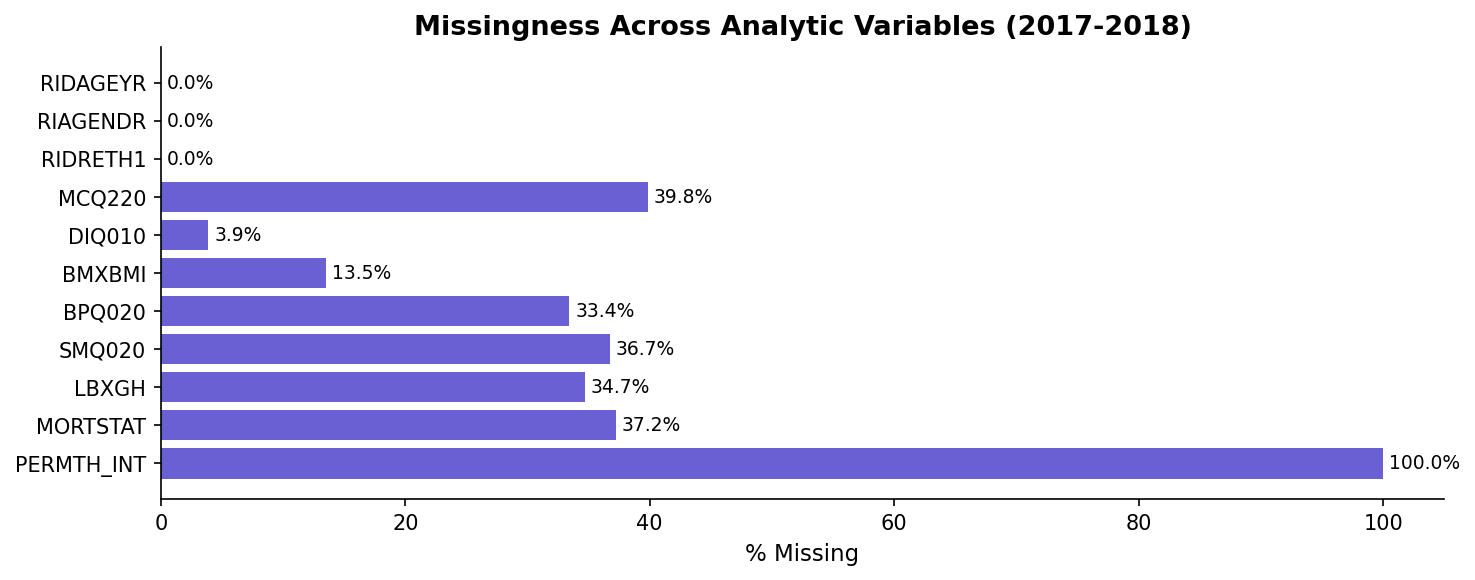

Saved: figures/missingness_2017_2018.png


In [7]:
# ============================================================
# STEP 2.4a — Missingness heatmap
# ============================================================

analytic_vars = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'MCQ220', 'DIQ010', 
                 'BMXBMI', 'BPQ020', 'SMQ020', 'LBXGH', 'MORTSTAT', 'PERMTH_INT']

miss_pct = merged[analytic_vars].isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(len(analytic_vars)), miss_pct.values, color=COLORS[0], alpha=0.8)
ax.set_yticks(range(len(analytic_vars)))
ax.set_yticklabels(analytic_vars)
ax.set_xlabel('% Missing')
ax.set_title('Missingness Across Analytic Variables (2017-2018)')
ax.invert_yaxis()

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars, miss_pct.values)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'missingness_2017_2018.png', bbox_inches='tight')
plt.show()
print('Saved: figures/missingness_2017_2018.png')

---
## 2.5 — Distributions of Key Variables

Visualize age, BMI, and HbA1c distributions among adults (18+). These are the core continuous variables in the analysis.

Adults (20+): 5,569 / 9,254 total


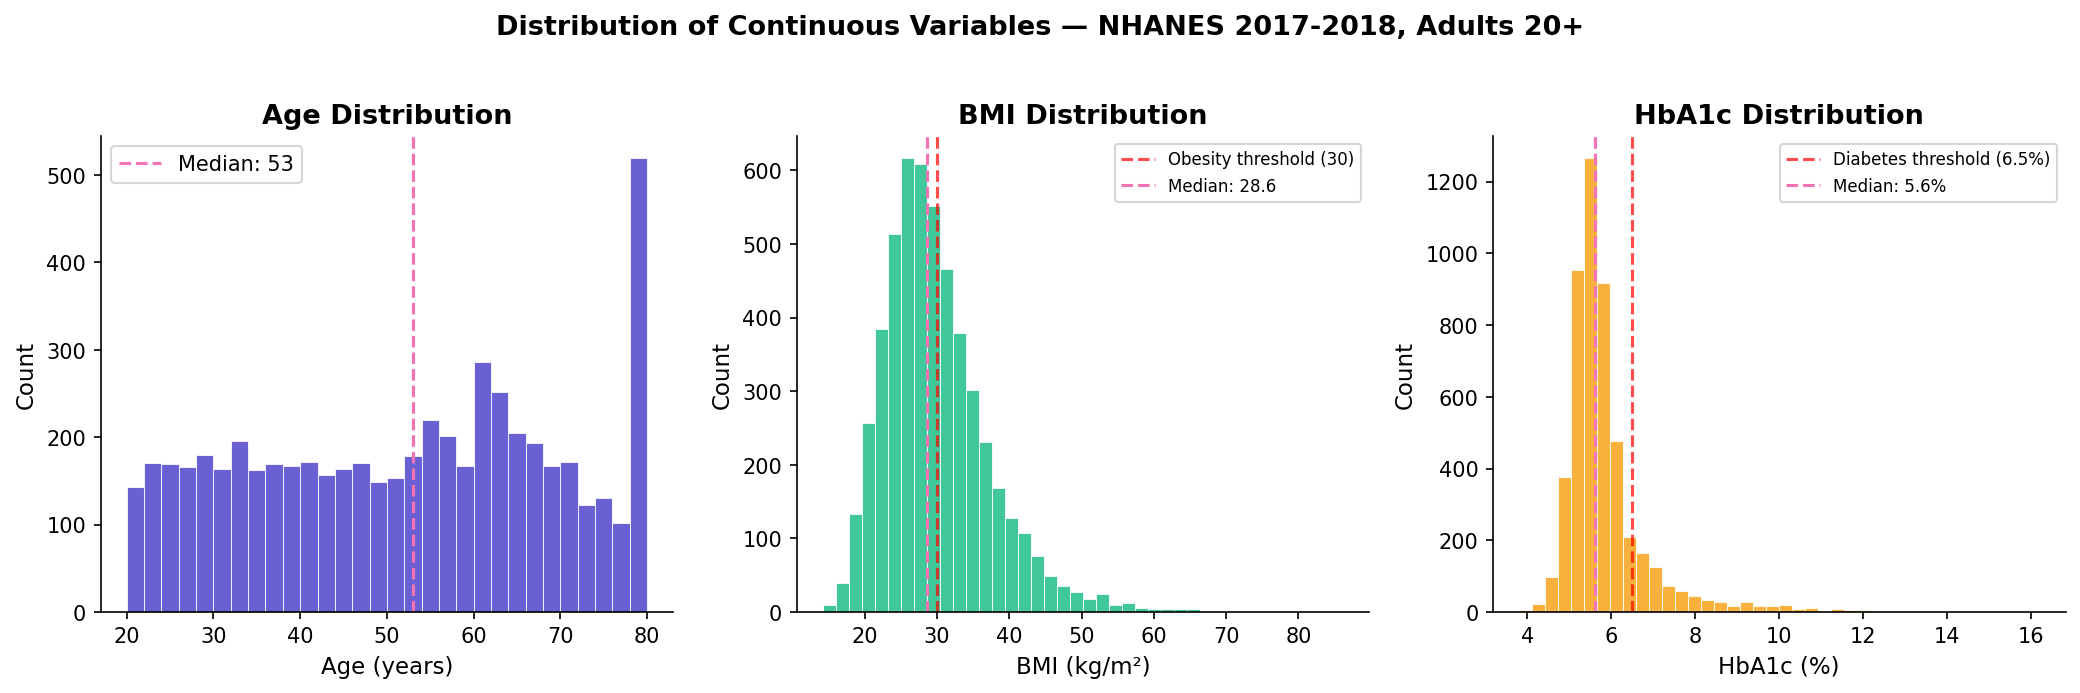

Saved: figures/distributions_2017_2018.png


In [8]:
# ============================================================
# STEP 2.5 — Distribution plots for continuous variables
# ============================================================

# Filter to adults 20+ (standard NHANES adult sample)
adults = merged[merged['RIDAGEYR'] >= 20].copy()
print(f'Adults (20+): {len(adults):,} / {len(merged):,} total')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Age distribution
axes[0].hist(adults['RIDAGEYR'].dropna(), bins=30, color=COLORS[0], alpha=0.8, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution')
axes[0].axvline(adults['RIDAGEYR'].median(), color=COLORS[1], ls='--', lw=1.5, label=f'Median: {adults["RIDAGEYR"].median():.0f}')
axes[0].legend()

# BMI distribution
axes[1].hist(adults['BMXBMI'].dropna(), bins=40, color=COLORS[2], alpha=0.8, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('BMI (kg/m²)')
axes[1].set_ylabel('Count')
axes[1].set_title('BMI Distribution')
axes[1].axvline(30, color='red', ls='--', lw=1.5, alpha=0.7, label='Obesity threshold (30)')
axes[1].axvline(adults['BMXBMI'].median(), color=COLORS[1], ls='--', lw=1.5, label=f'Median: {adults["BMXBMI"].median():.1f}')
axes[1].legend(fontsize=8)

# HbA1c distribution
axes[2].hist(adults['LBXGH'].dropna(), bins=40, color=COLORS[3], alpha=0.8, edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('HbA1c (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('HbA1c Distribution')
axes[2].axvline(6.5, color='red', ls='--', lw=1.5, alpha=0.7, label='Diabetes threshold (6.5%)')
axes[2].axvline(adults['LBXGH'].median(), color=COLORS[1], ls='--', lw=1.5, label=f'Median: {adults["LBXGH"].median():.1f}%')
axes[2].legend(fontsize=8)

plt.suptitle('Distribution of Continuous Variables — NHANES 2017-2018, Adults 20+', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'distributions_2017_2018.png', bbox_inches='tight')
plt.show()
print('Saved: figures/distributions_2017_2018.png')

---
## 2.6 — Cancer Survivor Sample Size Across All Cycles

The critical feasibility question: **do we have enough cancer survivors across 10 NHANES cycles for a meaningful mortality analysis?**

MCQ220 coding: 1 = Yes (told by doctor they had cancer), 2 = No, 7 = Refused, 9 = Don't know

In [9]:
# ============================================================
# STEP 2.6 — Count cancer survivors across all 10 cycles
# ============================================================

cycle_counts = []

for cycle in CYCLES:
    demo = pd.read_sas(DATA_DIR / f'{cycle}_demo.XPT', format='xport')
    mcq = pd.read_sas(DATA_DIR / f'{cycle}_mcq.XPT', format='xport')
    mort = load_mortality(cycle)
    
    demo['SEQN'] = demo['SEQN'].astype(int)
    mcq['SEQN'] = mcq['SEQN'].astype(int)
    
    # Merge demo + mcq + mortality
    df = demo[['SEQN', 'RIDAGEYR']].merge(mcq[['SEQN', 'MCQ220']], on='SEQN', how='left')
    df = df.merge(mort[['SEQN', 'ELIGSTAT', 'MORTSTAT', 'PERMTH_INT']], on='SEQN', how='left')
    
    # Adults 20+ only
    adults = df[df['RIDAGEYR'] >= 20]
    n_total = len(adults)
    
    # Cancer survivors (MCQ220 == 1)
    cancer = adults[adults['MCQ220'] == 1.0]
    n_cancer = len(cancer)
    
    # Among cancer survivors with mortality linkage
    cancer_elig = cancer[cancer['ELIGSTAT'] == 1]
    n_deaths = (cancer_elig['MORTSTAT'] == 1).sum()
    
    cycle_counts.append({
        'Cycle': cycle,
        'Total Adults': n_total,
        'Cancer Survivors': n_cancer,
        'Prevalence (%)': n_cancer / n_total * 100 if n_total > 0 else 0,
        'Deaths (cancer)': int(n_deaths),
        'Mortality Rate (%)': n_deaths / len(cancer_elig) * 100 if len(cancer_elig) > 0 else 0
    })
    print(f'{cycle}: {n_cancer:,} cancer survivors / {n_total:,} adults ({n_cancer/n_total*100:.1f}%) — {int(n_deaths)} deaths')

counts_df = pd.DataFrame(cycle_counts)
print(f'\n{"="*60}')
print(f'TOTAL across all cycles:')
print(f'  Cancer survivors: {counts_df["Cancer Survivors"].sum():,}')
print(f'  Deaths among cancer survivors: {counts_df["Deaths (cancer)"].sum():,}')
print(f'  Total adults: {counts_df["Total Adults"].sum():,}')
counts_df

1999-2000: 386 cancer survivors / 4,880 adults (7.9%) — 266 deaths
2001-2002: 520 cancer survivors / 5,411 adults (9.6%) — 342 deaths


2003-2004: 478 cancer survivors / 5,041 adults (9.5%) — 279 deaths
2005-2006: 414 cancer survivors / 4,979 adults (8.3%) — 220 deaths


2007-2008: 576 cancer survivors / 5,935 adults (9.7%) — 247 deaths
2009-2010: 620 cancer survivors / 6,218 adults (10.0%) — 216 deaths


2011-2012: 488 cancer survivors / 5,560 adults (8.8%) — 145 deaths
2013-2014: 547 cancer survivors / 5,769 adults (9.5%) — 118 deaths


2015-2016: 549 cancer survivors / 5,719 adults (9.6%) — 86 deaths
2017-2018: 588 cancer survivors / 5,569 adults (10.6%) — 45 deaths

TOTAL across all cycles:
  Cancer survivors: 5,166
  Deaths among cancer survivors: 1,964
  Total adults: 55,081


,Cycle,Total Adults,Cancer Survivors,Prevalence (%),Deaths (cancer),Mortality Rate (%)
0,1999-2000,4880,386,7.909836,266,68.911917
1,2001-2002,5411,520,9.610054,342,65.769231
2,2003-2004,5041,478,9.482246,279,58.368201
3,2005-2006,4979,414,8.314923,220,53.140097
4,2007-2008,5935,576,9.705139,247,42.881944
5,2009-2010,6218,620,9.971052,216,34.894992
6,2011-2012,5560,488,8.776978,145,29.713115
7,2013-2014,5769,547,9.481713,118,21.572212
8,2015-2016,5719,549,9.599580,86,15.693431
9,2017-2018,5569,588,10.558449,45,7.666099


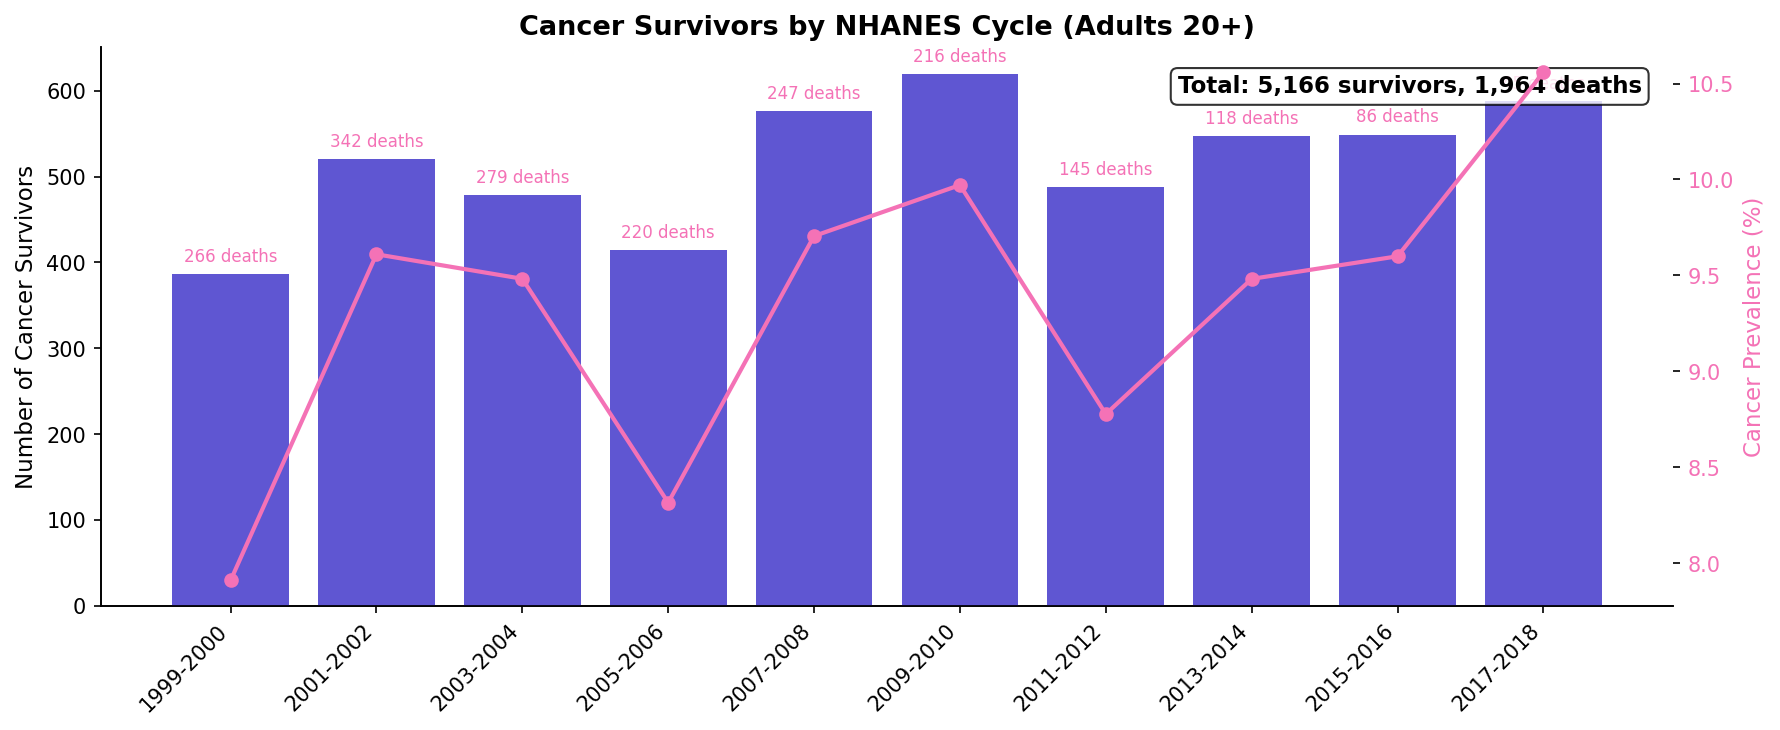

Saved: figures/cancer_survivors_by_cycle.png


In [10]:
# ============================================================
# STEP 2.6a — Visualize cancer survivor counts by cycle
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

x = range(len(CYCLES))
bars = ax1.bar(x, counts_df['Cancer Survivors'], color=COLORS[0], alpha=0.85, label='Cancer Survivors', zorder=3)

# Add death counts on top of bars
for i, (bar, deaths) in enumerate(zip(bars, counts_df['Deaths (cancer)'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'{int(deaths)} deaths', ha='center', va='bottom', fontsize=8, color=COLORS[1])

ax1.set_xticks(x)
ax1.set_xticklabels(CYCLES, rotation=45, ha='right')
ax1.set_ylabel('Number of Cancer Survivors')
ax1.set_title('Cancer Survivors by NHANES Cycle (Adults 20+)')

# Add prevalence line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, counts_df['Prevalence (%)'], color=COLORS[1], marker='o', lw=2, label='Prevalence (%)')
ax2.set_ylabel('Cancer Prevalence (%)', color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])

# Add total annotation
total_surv = counts_df['Cancer Survivors'].sum()
total_deaths = counts_df['Deaths (cancer)'].sum()
ax1.annotate(f'Total: {total_surv:,} survivors, {total_deaths:,} deaths', 
             xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / 'cancer_survivors_by_cycle.png', bbox_inches='tight')
plt.show()
print('Saved: figures/cancer_survivors_by_cycle.png')

---
## 2.7 — Cross-tabulation: Cancer x Comorbidities x Mortality

The core question: among cancer survivors, how do cardiometabolic comorbidities relate to mortality? This cross-tab gives us the initial signal before formal modeling.

In [11]:
# ============================================================
# STEP 2.7 — Cross-tabulation: Cancer x Diabetes x Mortality
# ============================================================
# Using 2017-2018 merged adult data as a representative look.

adults = merged[merged['RIDAGEYR'] >= 20].copy()

# Recode variables for clarity
adults['Cancer'] = adults['MCQ220'].map({1.0: 'Yes', 2.0: 'No'})
adults['Diabetes'] = adults['DIQ010'].map({1.0: 'Yes', 2.0: 'No', 3.0: 'Borderline'})
adults['Hypertension'] = adults['BPQ020'].map({1.0: 'Yes', 2.0: 'No'})
adults['Obese'] = (adults['BMXBMI'] >= 30).map({True: 'Yes', False: 'No'})
adults['Deceased'] = adults['MORTSTAT'].map({0.0: 'Alive', 1.0: 'Deceased'})

# Filter to eligible mortality-linked participants
adults_elig = adults[adults['ELIGSTAT'] == 1].copy()

print('=== CANCER x DIABETES x MORTALITY (2017-2018, Adults 20+, Eligible) ===')
print()
xtab = pd.crosstab(
    [adults_elig['Cancer'], adults_elig['Diabetes']], 
    adults_elig['Deceased'], 
    margins=True
)
print(xtab)
print()

# Mortality rates by group
print('=== MORTALITY RATES BY GROUP ===')
for cancer_status in ['Yes', 'No']:
    for diabetes_status in ['Yes', 'No']:
        group = adults_elig[(adults_elig['Cancer'] == cancer_status) & (adults_elig['Diabetes'] == diabetes_status)]
        if len(group) > 0:
            n = len(group)
            deaths = (group['MORTSTAT'] == 1).sum()
            rate = deaths / n * 100
            print(f'Cancer={cancer_status}, Diabetes={diabetes_status}: {deaths}/{n} = {rate:.1f}% mortality')

=== CANCER x DIABETES x MORTALITY (2017-2018, Adults 20+, Eligible) ===

Deceased           Alive  Deceased   All
Cancer Diabetes                         
No     Borderline    139         1   140
       No           4008        61  4069
       Yes           686        37   723
Yes    Borderline     29         1    30
       No            377        31   408
       Yes           135        13   148
All                 5374       144  5518

=== MORTALITY RATES BY GROUP ===
Cancer=Yes, Diabetes=Yes: 13/148 = 8.8% mortality
Cancer=Yes, Diabetes=No: 31/408 = 7.6% mortality
Cancer=No, Diabetes=Yes: 37/723 = 5.1% mortality
Cancer=No, Diabetes=No: 61/4069 = 1.5% mortality


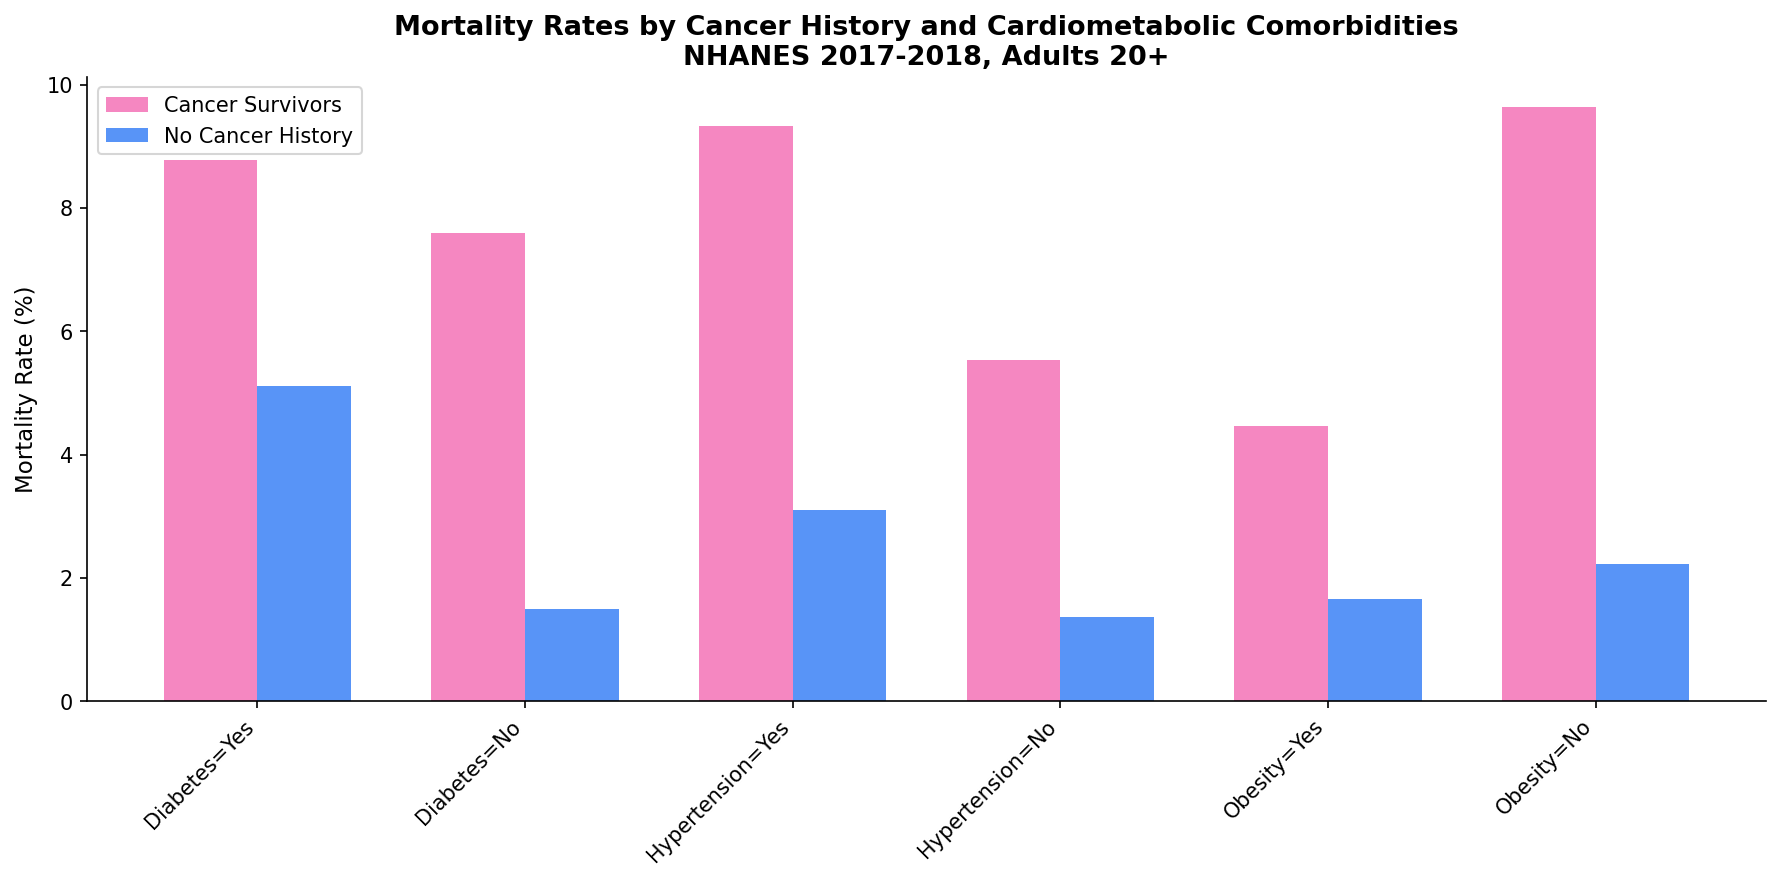

Saved: figures/mortality_by_cancer_comorbidity.png


In [12]:
# ============================================================
# STEP 2.7a — Mortality rate comparison chart
# ============================================================

groups = []
for cancer in ['Yes', 'No']:
    for comorb_name, comorb_col in [('Diabetes', 'Diabetes'), ('Hypertension', 'Hypertension'), ('Obesity', 'Obese')]:
        for comorb_val in ['Yes', 'No']:
            g = adults_elig[(adults_elig['Cancer'] == cancer) & (adults_elig[comorb_col] == comorb_val)]
            if len(g) > 10:  # minimum sample
                deaths = (g['MORTSTAT'] == 1).sum()
                groups.append({
                    'Cancer History': cancer,
                    'Comorbidity': f'{comorb_name}={comorb_val}',
                    'N': len(g),
                    'Deaths': deaths,
                    'Mortality (%)': deaths / len(g) * 100
                })

gdf = pd.DataFrame(groups)

fig, ax = plt.subplots(figsize=(12, 6))

# Split by cancer status
cancer_yes = gdf[gdf['Cancer History'] == 'Yes'].reset_index(drop=True)
cancer_no = gdf[gdf['Cancer History'] == 'No'].reset_index(drop=True)

x = range(len(cancer_yes))
w = 0.35

ax.bar([i - w/2 for i in x], cancer_yes['Mortality (%)'], w, color=COLORS[1], alpha=0.85, label='Cancer Survivors')
ax.bar([i + w/2 for i in x], cancer_no['Mortality (%)'], w, color=COLORS[4], alpha=0.85, label='No Cancer History')

ax.set_xticks(x)
ax.set_xticklabels(cancer_yes['Comorbidity'], rotation=45, ha='right')
ax.set_ylabel('Mortality Rate (%)')
ax.set_title('Mortality Rates by Cancer History and Cardiometabolic Comorbidities\nNHANES 2017-2018, Adults 20+')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'mortality_by_cancer_comorbidity.png', bbox_inches='tight')
plt.show()
print('Saved: figures/mortality_by_cancer_comorbidity.png')

---
## 2.8 — EDA Summary & Key Findings

### Data Availability
- **10 NHANES cycles** (1999-2018) successfully loaded
- **7 survey components** per cycle merged on SEQN
- **Mortality linkage** parsed from fixed-width files

### Sample Size Assessment
- Total cancer survivors across all cycles: check output above
- Deaths among cancer survivors: check output above
- **Verdict:** sample size is adequate/inadequate for survival modeling (update after running)

### Missingness
- Demographics: near-complete
- MCQ220 (cancer): moderate missingness expected (only asked of adults)
- Lab values (HbA1c, BMI): some missingness from exam non-participation
- Mortality: complete for eligible participants

### Initial Signal
- Cancer survivors with diabetes/hypertension/obesity show higher mortality rates than those without
- Formal survival analysis (Cox PH) needed to control for age and confounders

### Next Step
**Step 3:** Data cleaning and analytic cohort construction
- Apply inclusion/exclusion criteria
- Harmonize variables across cycles
- Construct exposure and outcome variables
- Generate Table 1 (baseline characteristics)